# Notebook 05 — Training
**Run after:** `04_loss_functions.ipynb`

## ⚠️ Time Warning
- **Quick test** (2 epochs per stage): ~15-20 minutes
- **Full training** (5 + 25 epochs): ~6-8 hours

**Recommended workflow:**
1. Run the quick test first to verify everything works
2. Then change `QUICK_MODE = False` and start a full run
3. If interrupted: re-run — the script loads the last checkpoint automatically

## What Happens Each Epoch
After every epoch you'll see:
```
Train → Loss: 1.2345 | F1: 0.4321 | AUROC: 0.8123
Val   → Loss: 1.1234 | F1: 0.4789 | AUROC: 0.8345
```
Watch F1 climb from ~0.2 (random) toward ~0.75-0.82 (trained).


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')
import warnings; warnings.filterwarnings('ignore')
import torch
import json
from collections import Counter

from data.dataset    import load_metadata, split_dataset, get_dataloaders
from models.architecture import RobustMedicalClassifier
from models.losses   import CombinedLoss
from models.trainer  import get_device, train, validate

METADATA_CSV = 'dataset/HAM10000_metadata.csv'
IMAGES_DIR   = 'dataset/images'
OUTPUTS_DIR  = 'outputs'

# ── SET THIS ─────────────────────────────────────────────
QUICK_MODE  = False    # Change to False for full training
BATCH_SIZE  = 16
# ─────────────────────────────────────────────────────────

device = get_device()
print(f"Device: {device}")
print(f"Quick mode: {QUICK_MODE}")


  Device: Apple M2 GPU (MPS) ✅ — training will use GPU cores
Device: mps
Quick mode: False


In [3]:
print("Loading data...")
df = load_metadata(METADATA_CSV, IMAGES_DIR)
df_train, df_val, df_test = split_dataset(df)
train_loader, val_loader, test_loader = get_dataloaders(
    df_train, df_val, df_test, batch_size=BATCH_SIZE
)
class_counts = dict(Counter(df_train['label'].values))
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")


Loading data...
STEP 1B: Loading HAM10000 Metadata
  Total records in CSV: 10015
  Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']
  Unique lesions (lesion_id): 7470
  Unique images (image_id):   10015
  All 10015 images found on disk. ✅

  Class distribution:
    akiec  (Actinic Keratosis        ):   327 (3.3%)
    bcc    (Basal Cell Carcinoma     ):   514 (5.1%)
    bkl    (Benign Keratosis         ):  1099 (11.0%)
    df     (Dermatofibroma           ):   115 (1.1%)
    mel    (Melanoma                 ):  1113 (11.1%)
    nv     (Melanocytic Nevus        ):  6705 (66.9%)
    vasc   (Vascular Lesion          ):   142 (1.4%)

STEP 1C: Group-Based Train/Val/Test Split
WHY: Splitting by lesion_id prevents same lesion in train+test
  Train:  6959 images | 5228 unique lesions
  Val:    1529 images | 1121 unique lesions
  Test:   1527 images | 1121 unique lesions
  No data leakage detected ✅

STEP 1G: Creating DataLoaders
  Batch size: 16 (safe

In [4]:
print("Building model...")
model = RobustMedicalClassifier(num_classes=7, freeze_backbone=True)
model = model.to(device)

# Load checkpoint if one exists (auto-resume)
import os
ckpt_path = os.path.join(OUTPUTS_DIR, 'best_model.pth')
if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Resumed from checkpoint — epoch {ckpt['epoch']}, val F1: {ckpt['val_f1']:.4f}")
else:
    print("Starting fresh — no checkpoint found")


Building model...
  Backbone FROZEN (Stage 1 training)
Starting fresh — no checkpoint found


In [5]:
loss_fn = CombinedLoss(
    num_classes=7, gamma=2.0, lambda_ev=0.5,
    class_counts=class_counts, device=device
)


  Focal alpha (per-class weights): [0.007 0.041 0.041 0.09  0.142 0.338 0.342]
  Combined Loss: Focal(γ=2.0) + 0.5×Evidential


## Stage 1 — Frozen Backbone
Only the classification head trains. The EfficientNet backbone stays frozen.
Why: Let the head adapt to skin lesions without destroying ImageNet features.
Expected: F1 climbs from ~0.2 to ~0.5 in 5 epochs.


In [6]:
stage1_epochs = 2 if QUICK_MODE else 5
stage2_epochs = 2 if QUICK_MODE else 25

history = train(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    loss_fn       = loss_fn,
    device        = device,
    output_dir    = OUTPUTS_DIR,
    stage1_epochs = stage1_epochs,
    stage2_epochs = stage2_epochs,
    batch_size    = BATCH_SIZE,
)
print("\nTraining complete ✅")



STAGE 1: Frozen Backbone Training
  Epochs: 1 to 5
  WHY: Head learns medical features; backbone stays intact
  Backbone FROZEN (Stage 1 training)

  Optimizer: AdamW
    Backbone LR: 0.0 (frozen in Stage 1, gentle in Stage 2)
    Head LR:     0.001
    Weight decay: 0.0001
  Scheduler: CosineAnnealingWarmRestarts(T_0=5, T_mult=1)

  Epoch 1/5
    Batch 50/434 | Loss: 1.0591 | Focal: 0.1034 | Ev: 1.9115
    Batch 100/434 | Loss: 0.9893 | Focal: 0.0787 | Ev: 1.8212
    Batch 150/434 | Loss: 0.8732 | Focal: 0.0497 | Ev: 1.6471
    Batch 200/434 | Loss: 0.9634 | Focal: 0.0596 | Ev: 1.8077
    Batch 250/434 | Loss: 0.9825 | Focal: 0.0832 | Ev: 1.7987
    Batch 300/434 | Loss: 0.7401 | Focal: 0.0349 | Ev: 1.4103
    Batch 350/434 | Loss: 0.9796 | Focal: 0.1432 | Ev: 1.6728
    Batch 400/434 | Loss: 0.8595 | Focal: 0.0608 | Ev: 1.5975

  ─── Epoch 1 Results (Stage 1) ───
  Train  → Loss: 0.9774 | F1: 0.3098 | AUROC: 0.7783
  Val    → Loss: 0.7796   | F1: 0.2193 | AUROC: 0.8288
  Time:  203.

Python(23454) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23456) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



  ─── Epoch 6 Results (Stage 2) ───
  Train  → Loss: 0.7948 | F1: 0.5238 | AUROC: 0.8878
  Val    → Loss: 0.7177   | F1: 0.3297 | AUROC: 0.8689
  Time:  912.2s
    ✅ New best val F1: 0.3297 — checkpoint saved

  Epoch 7/30


Python(23621) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(23640) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


    Batch 50/434 | Loss: 0.7136 | Focal: 0.0298 | Ev: 1.3675
    Batch 100/434 | Loss: 1.0189 | Focal: 0.0600 | Ev: 1.9178
    Batch 150/434 | Loss: 0.6440 | Focal: 0.0269 | Ev: 1.2341
    Batch 200/434 | Loss: 0.7967 | Focal: 0.0441 | Ev: 1.5051
    Batch 250/434 | Loss: 0.9011 | Focal: 0.0588 | Ev: 1.6845
    Batch 300/434 | Loss: 0.7117 | Focal: 0.0363 | Ev: 1.3509
    Batch 350/434 | Loss: 0.8054 | Focal: 0.0806 | Ev: 1.4496
    Batch 400/434 | Loss: 0.7300 | Focal: 0.0563 | Ev: 1.3474


...


  ─── Epoch 29 Results (Stage 2) ───
  Train  → Loss: 0.4959 | F1: 0.8009 | AUROC: 0.9718
  Val    → Loss: 0.6805   | F1: 0.5837 | AUROC: 0.9326
  Time:  304.7s
    ✅ New best val F1: 0.5837 — checkpoint saved

  Epoch 30/30


Python(70920) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(70935) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


    Batch 50/434 | Loss: 0.6643 | Focal: 0.0220 | Ev: 1.2846
    Batch 100/434 | Loss: 0.7971 | Focal: 0.0300 | Ev: 1.5342
    Batch 150/434 | Loss: 0.2786 | Focal: 0.0058 | Ev: 0.5456
    Batch 200/434 | Loss: 0.8894 | Focal: 0.0245 | Ev: 1.7297
    Batch 250/434 | Loss: 0.8694 | Focal: 0.0136 | Ev: 1.7116
    Batch 300/434 | Loss: 1.0319 | Focal: 0.0466 | Ev: 1.9706
    Batch 350/434 | Loss: 0.5264 | Focal: 0.0094 | Ev: 1.0341
    Batch 400/434 | Loss: 0.4654 | Focal: 0.0087 | Ev: 0.9133


Python(71686) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(71687) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



  ─── Epoch 30 Results (Stage 2) ───
  Train  → Loss: 0.5260 | F1: 0.7812 | AUROC: 0.9660
  Val    → Loss: 0.7392   | F1: 0.5448 | AUROC: 0.9241
  Time:  246.5s
    No improvement for 1/7 epochs (best F1: 0.5837)

  Training history saved to: outputs/training_history.json
  Best model saved to: outputs/best_model.pth

Training complete ✅


## Training History Plots

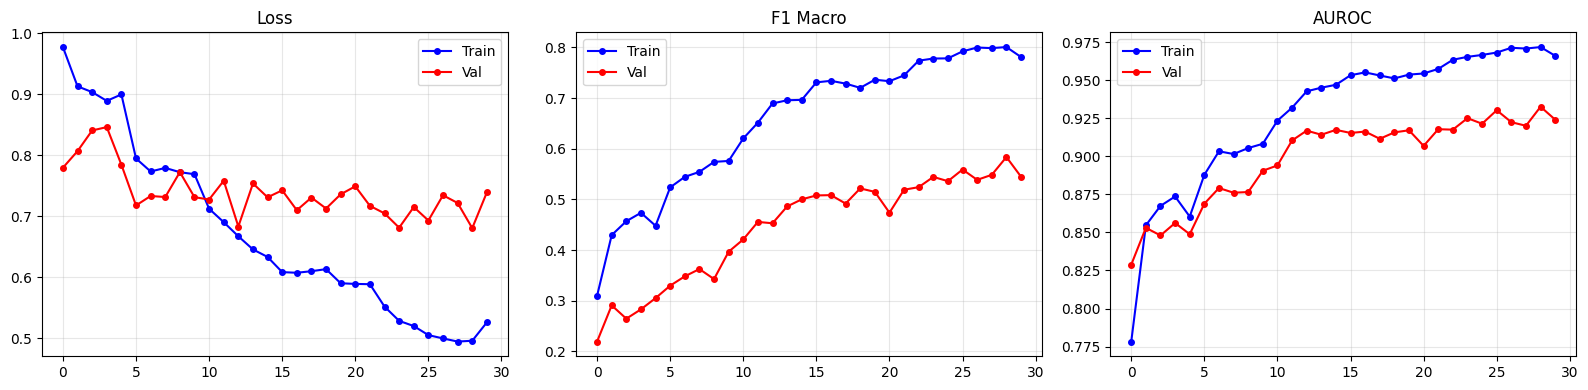


→ NEXT: Open notebook 06_evaluate.ipynb


In [7]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

history_img = os.path.join(OUTPUTS_DIR, 'training_history.png')
if os.path.exists(history_img):
    img = mpimg.imread(history_img)
    plt.figure(figsize=(16, 4))
    plt.imshow(img); plt.axis('off'); plt.tight_layout(); plt.show()
else:
    # Plot from history dict directly
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, (tk, vk, title) in zip(axes, [
        ('train_loss', 'val_loss', 'Loss'),
        ('train_f1_macro', 'val_f1_macro', 'F1 Macro'),
        ('train_auroc', 'val_auroc', 'AUROC'),
    ]):
        if tk in history: ax.plot(history[tk], 'b-o', ms=4, label='Train')
        if vk in history: ax.plot(history[vk], 'r-o', ms=4, label='Val')
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

print("\n→ NEXT: Open notebook 06_evaluate.ipynb")
